# 01 — CROHME EXPLORATION


In [ ]:
#helper function to display the path in a more readable format
def display_path(path):
    return "/abhista/HMER" + str(path).split("/HMER", 1)[1]

In [2]:
from pathlib import Path
import sys
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.inkml_parser import parse_inkml


DATASET_ROOT = PROJECT_ROOT / "data" / "crohme2019"

TRAIN_DIR = DATASET_ROOT / "train"
VALID_DIR = DATASET_ROOT / "valid"
TEST_DIR = DATASET_ROOT / "test"

print(f"Project root: {display_path(PROJECT_ROOT)}")
print(f"Dataset root:   {display_path(DATASET_ROOT)}")

Project root: /abhista/HMER
Dataset root:   /abhista/HMER/data/crohme2019


In [3]:
train_files = sorted(TRAIN_DIR.glob("*.inkml"))
valid_files = sorted(VALID_DIR.glob("*.inkml"))
test_files = sorted(TEST_DIR.glob("*.inkml"))

print(f"Train: {len(train_files)}")
print(f"Valid: {len(valid_files)}")
print(f"Test:  {len(test_files)}")
print(f"Total: {len(train_files) + len(valid_files) + len(test_files)}")

Train: 8901
Valid: 986
Test:  1199
Total: 11086


In [4]:
def inspect_split(files, split_name):
    records = []

    for file_path in files:

        try:
            result = parse_inkml(file_path)

            strokes = result["strokes"]
            latex = result["latex"] or ""

            num_strokes = len(strokes)

            num_points = sum(
                len(stroke)
                for stroke in strokes
            )

            all_points = [
                point
                for stroke in strokes
                for point in stroke
            ]

            if all_points:
                xs = [p[0] for p in all_points]
                ys = [p[1] for p in all_points]

                width = max(xs) - min(xs)
                height = max(ys) - min(ys)

            else:
                width = 0
                height = 0

            records.append(
                {
                    "split": split_name,
                    "file": file_path.name,
                    "latex": latex,
                    "num_strokes": num_strokes,
                    "num_points": num_points,
                    "width": width,
                    "height": height,
                }
            )

        except Exception as exc:
            print(
                f"Failed to parse {file_path.name}: {exc}"
            )

    return pd.DataFrame(records)

In [5]:
train_df = inspect_split(
    train_files,
    "train",
)

valid_df = inspect_split(
    valid_files,
    "valid",
)

test_df = inspect_split(
    test_files,
    "test",
)

Failed to parse MfrDB0104.inkml: not well-formed (invalid token): line 15, column 23


In [6]:
df = pd.concat(
    [
        train_df,
        valid_df,
        test_df,
    ],
    ignore_index=True,
)

print(df.shape)

(11085, 7)


In [7]:
df[
    [
        "num_strokes",
        "num_points",
        "width",
        "height",
    ]
].describe()

,num_strokes,num_points,width,height
count,11085.000000,11085.000000,11085.000000,11085.000000
mean,13.912494,463.846820,2289.590989,895.260627
std,10.094747,433.591151,3519.824007,1294.860183
min,1.000000,17.000000,0.172740,0.070370
25%,6.000000,175.000000,180.000000,71.000000
50%,12.000000,354.000000,695.000000,195.000000
75%,20.000000,617.000000,2782.000000,1451.000000
max,115.000000,6581.000000,24475.000000,13114.000000


In [8]:
df["aspect_ratio"] = (
    df["width"] /
    df["height"].replace(0, np.nan)
)

In [9]:
df["aspect_ratio"].describe()

count    11085.000000
mean         3.896772
std          2.988968
min          0.020202
25%          1.906667
50%          3.091398
75%          4.918421
max         25.230607
Name: aspect_ratio, dtype: float64

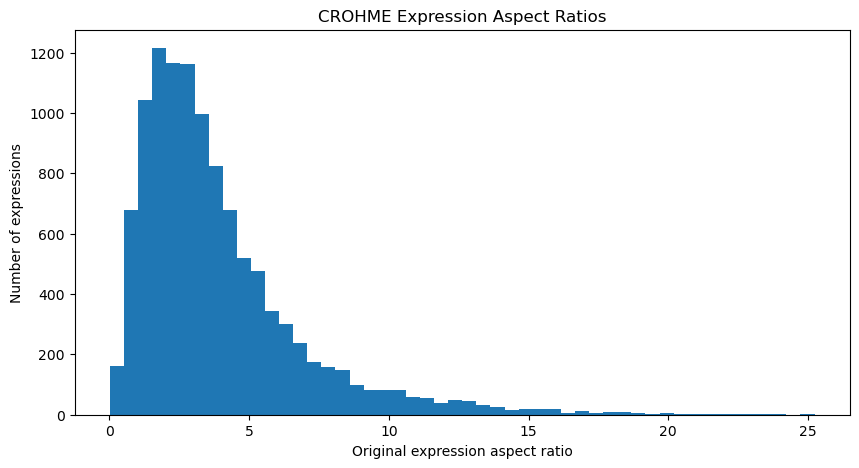

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["aspect_ratio"].dropna(),
    bins=50,
)

plt.xlabel("Original expression aspect ratio")
plt.ylabel("Number of expressions")
plt.title("CROHME Expression Aspect Ratios")

plt.show()

In [11]:
df["num_strokes"].describe()

count    11085.000000
mean        13.912494
std         10.094747
min          1.000000
25%          6.000000
50%         12.000000
75%         20.000000
max        115.000000
Name: num_strokes, dtype: float64

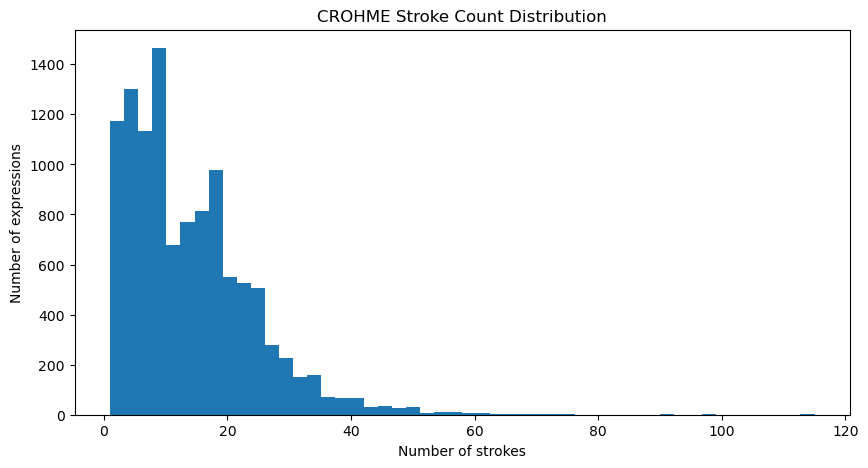

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["num_strokes"],
    bins=50,
)

plt.xlabel("Number of strokes")
plt.ylabel("Number of expressions")
plt.title("CROHME Stroke Count Distribution")

plt.show()

In [13]:
df["latex_length"] = df["latex"].str.len()

In [14]:
df["latex_length"].describe()

count    11085.000000
mean        31.065674
std         21.242644
min          1.000000
25%         15.000000
50%         27.000000
75%         43.000000
max        300.000000
Name: latex_length, dtype: float64

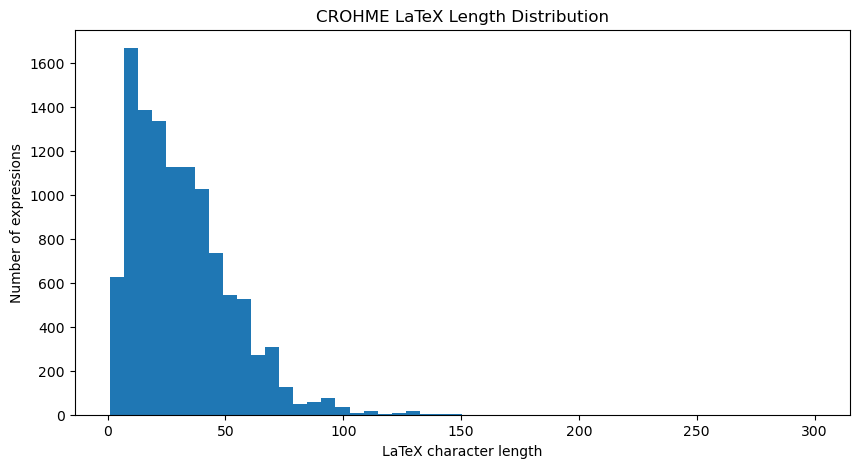

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["latex_length"],
    bins=50,
)

plt.xlabel("LaTeX character length")
plt.ylabel("Number of expressions")
plt.title("CROHME LaTeX Length Distribution")

plt.show()

In [16]:
df.nlargest(
    10,
    "latex_length"
)[
    [
        "file",
        "latex",
        "latex_length",
        "num_strokes",
    ]
]

,file,latex,latex_length,num_strokes
9310,505_em_51.inkml,$|x^{\frac{1}{n}} - c^{\frac{1}{n}}| = \frac{|...,300,115
8896,stat13.inkml,$ \log x(t) = \sum_{k=1}^{\infty} \frac{a_{k}}...,219,99
9557,519_em_448.inkml,$\left ( \left ( \frac{1}{4} \left ( 3 \right...,172,34
9669,RIT_2014_185.inkml,$ \lim \limits _ {n \rightarrow \infty} n \sin...,148,47
2670,200924-1331-130.inkml,\frac { { \frac { b } { { \mbox { P } } ^ { { ...,147,17
8412,formulaire032-equation014.inkml,$\frac{\pi^2}{8} = \frac{1}{1^2} + \frac{1}{3^...,142,64
9818,RIT_2014_38.inkml,$ - \frac {11} {12} y _ {n + 1} + \frac {5} {3...,142,45
6728,formulaire006-equation024.inkml,$\frac{\pi}{4} = 1 - \frac{1}{3} + \frac{1}{5}...,140,68
6918,formulaire009-equation014.inkml,$p = \frac{{v_{0}}^{2} \sin(2\alpha)}{2a} + \s...,138,55
9698,RIT_2014_210.inkml,$ \frac {1} {4} + \frac {2} {5} = \frac {1 \ti...,135,46


In [17]:
df["has_dollar"] = df["latex"].str.contains(
    r"\$",
    regex=True,
)

df["has_dollar"].value_counts()

has_dollar
True     7000
False    4085
Name: count, dtype: int64